# Кластеризация данных о поведении клиентов онлайн-магазинов
Цель: выявить основные группы клиентов, исходя из их поведения методом K-Means

## EDA

Импорт необходимых библиотек

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import files

Загрузка и просмотр основной информации о данных

In [ ]:
df = pd.read_csv(files.upload().keys()[0]) # Загрузка данных из csv

In [ ]:
df.head() # Первые 5 строк

,customer_id,gender,age,country,device_type,product_category,time_spent_minutes,items_viewed,items_purchased,total_spent_usd
0,CUST_1,Male,40,Australia,Tablet,Clothing,87,12,8,1187
1,CUST_2,Female,38,Pakistan,Tablet,Electronics,71,22,3,153
2,CUST_3,Male,36,UK,Tablet,Clothing,59,20,8,1055
3,CUST_4,Male,36,Pakistan,Mobile,Clothing,39,18,3,991
4,CUST_5,Male,53,Canada,Desktop,Electronics,3,1,1,588


In [ ]:
df.info() # Информация о столбцах

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   customer_id         1800 non-null   str  
 1   gender              1800 non-null   str  
 2   age                 1800 non-null   int64
 3   country             1800 non-null   str  
 4   device_type         1800 non-null   str  
 5   product_category    1800 non-null   str  
 6   time_spent_minutes  1800 non-null   int64
 7   items_viewed        1800 non-null   int64
 8   items_purchased     1800 non-null   int64
 9   total_spent_usd     1800 non-null   int64
dtypes: int64(5), str(5)
memory usage: 140.8 KB


In [ ]:
df.describe() # Основные статистические показатели

,age,time_spent_minutes,items_viewed,items_purchased,total_spent_usd
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,41.144444,60.544444,24.542778,4.606667,778.503333
std,13.481514,34.717237,14.041840,2.852841,434.788777
min,18.000000,1.000000,1.000000,0.000000,5.000000
25%,30.000000,30.000000,13.000000,2.000000,400.750000
50%,41.000000,60.000000,24.000000,5.000000,802.000000
75%,53.000000,91.000000,36.000000,7.000000,1146.250000
max,64.000000,119.000000,49.000000,9.000000,1499.000000


Удаление ненужного столбца customer_id

In [ ]:
df.drop('customer_id', axis=1, inplace=True) # Удаление

Визуализация распределения данных

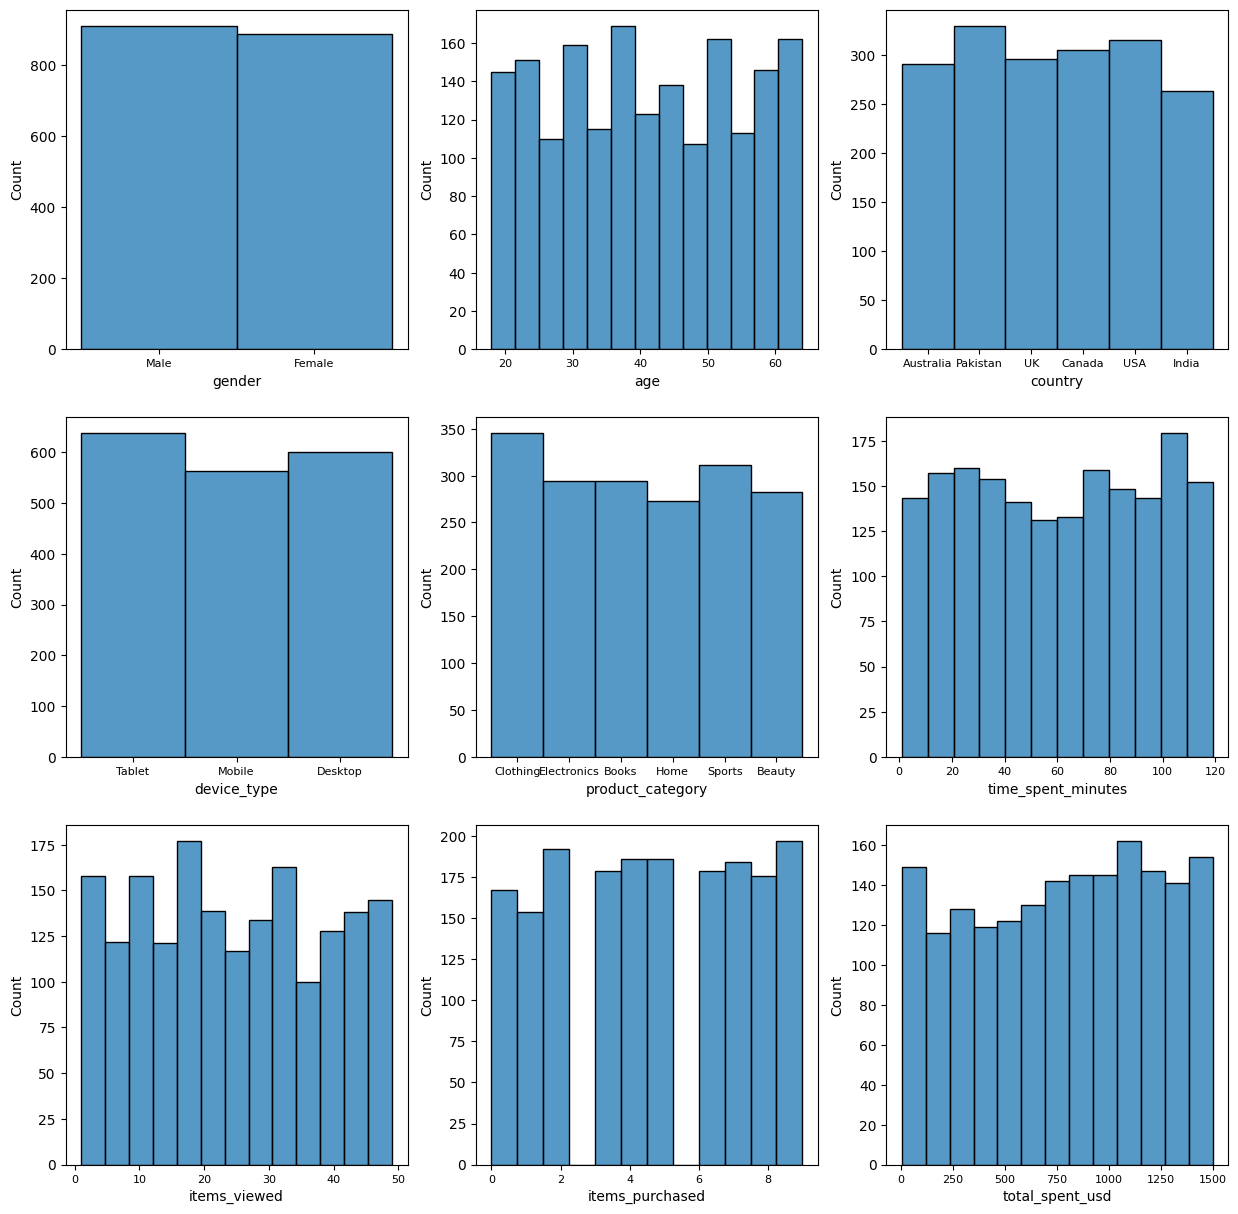

In [ ]:
inx = 1
plt.figure(figsize=(15, 15))

for col in df.columns:
    plt.subplot(3, 3, inx)
    sns.histplot(df[col]) # Гистограмма распределения
    plt.xticks(fontsize=8)
    inx += 1
plt.show()

Визуализация IQR

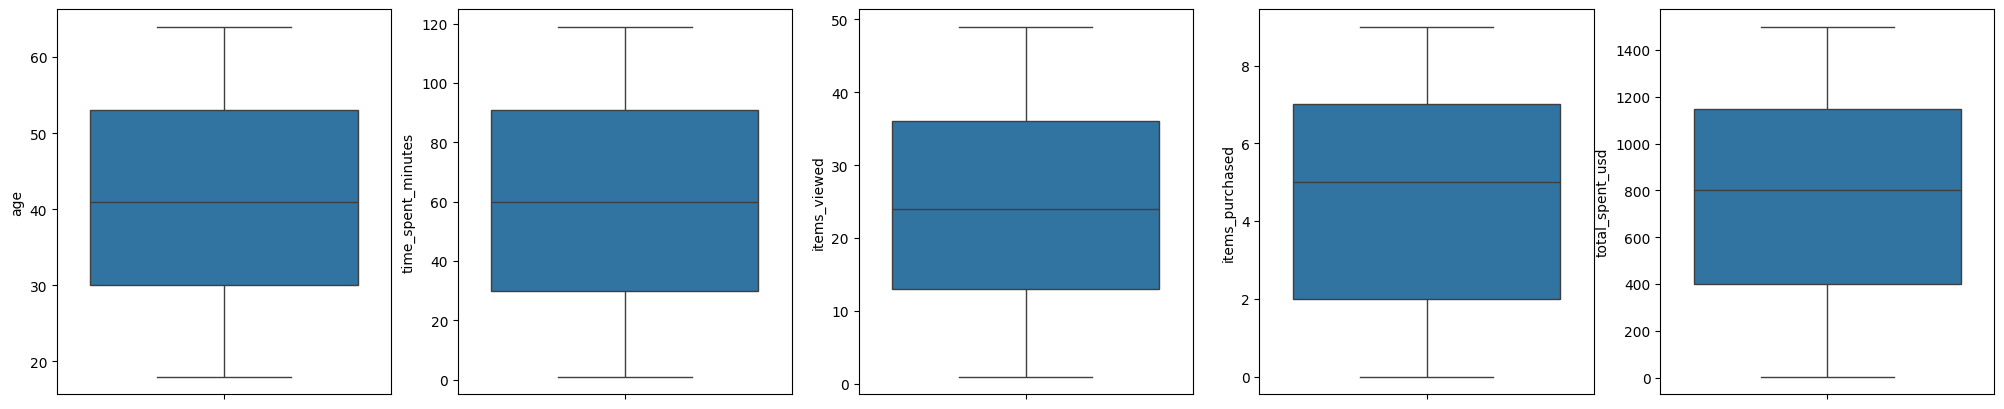

In [ ]:
inx = 1
plt.figure(figsize=(25, 5))

for col in df.select_dtypes(include='int64').columns:
    plt.subplot(1, 5, inx)
    sns.boxplot(df[col]) # Построение боксплота
    inx += 1
plt.show()

## Предобработка данных

One-Hot encoding, (подходит, т.к. категориальные переменные содержат мало классов)

In [ ]:
df_transformed = df

In [ ]:
for col in df_transformed.select_dtypes(include='str').columns:
    dummies = pd.get_dummies(df_transformed[col],
                             prefix=col).astype('int64') # Создание dummy-переменных
    df_transformed = pd.concat([df_transformed, dummies], axis=1)
    df_transformed.drop(col, axis=1, inplace=True) # Удаление признака

In [8]:
df_transformed.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   age                           1800 non-null   int64
 1   time_spent_minutes            1800 non-null   int64
 2   items_viewed                  1800 non-null   int64
 3   items_purchased               1800 non-null   int64
 4   total_spent_usd               1800 non-null   int64
 5   gender_Female                 1800 non-null   int64
 6   gender_Male                   1800 non-null   int64
 7   country_Australia             1800 non-null   int64
 8   country_Canada                1800 non-null   int64
 9   country_India                 1800 non-null   int64
 10  country_Pakistan              1800 non-null   int64
 11  country_UK                    1800 non-null   int64
 12  country_USA                   1800 non-null   int64
 13  device_type_Desktop           1800 non-null 

Масштабирование признаков с помощью MinMaxScaling (подходит, т.к. в данных нет выбросов)

In [9]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()

for col in df_transformed.select_dtypes(include='int64').columns:
    df_transformed[col] = scaler.fit_transform(df_transformed[[col]]) # Масштабирование

In [11]:
df_transformed.head()

,age,time_spent_minutes,items_viewed,items_purchased,total_spent_usd,gender_Female,gender_Male,country_Australia,country_Canada,country_India,...,country_USA,device_type_Desktop,device_type_Mobile,device_type_Tablet,product_category_Beauty,product_category_Books,product_category_Clothing,product_category_Electronics,product_category_Home,product_category_Sports
0,0.478261,0.728814,0.229167,0.888889,0.791165,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.434783,0.593220,0.437500,0.333333,0.099063,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.391304,0.491525,0.395833,0.888889,0.702811,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.391304,0.322034,0.354167,0.333333,0.659973,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.760870,0.016949,0.000000,0.111111,0.390228,0.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


Снижение размерности до 2 компонент с помощью t-SNE

In [12]:
from sklearn.manifold import TSNE

In [ ]:
df_transformed = TSNE(n_components=2).fit_transform(df_transformed) # Трансформирование в 2D 

## Кластеризация методом K-Means

In [14]:
from sklearn.cluster import KMeans

Подбор оптимального k методом локтя

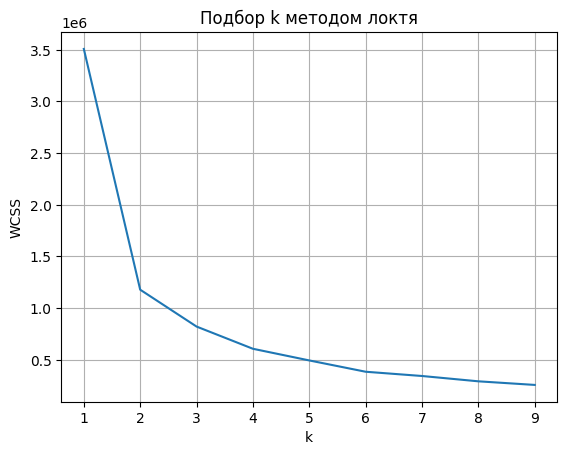

In [ ]:
wcss = {}

for k in range(1, 10): # Перебираем k от 1 до 9
    kmeans = KMeans(n_clusters=k,
                    max_iter=1000).fit(df_transformed) # K-Means
    wcss[k] = kmeans.inertia_ # Внутрикластерная сумма квадратов

plt.plot(list(wcss.keys()),
         list(wcss.values())) # Визуализация метода локтя
plt.title("Подбор k методом локтя")
plt.xlabel("k")
plt.ylabel("WCSS")
plt.grid()
plt.show()

Оптимальное значение k = 2 (после k = 2 появляется излом)

Обучим модель K-Means (k = 2) и сделаем визуализацию

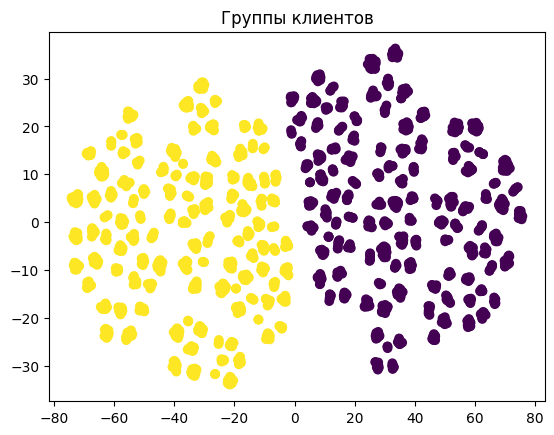

In [ ]:
kmeans = KMeans(n_clusters=2,
                max_iter=1000).fit(df_transformed) # K-Means с k = 2
labels = kmeans.labels_ # Метки кластеров
plt.scatter(df_transformed[:, 0], df_transformed[:, 1], c=labels) # Точечный график
plt.title("Группы клиентов")
plt.show()

## Оценка результатов кластеризации

Расчет коэффициента силуэта

In [17]:
from sklearn.metrics import silhouette_score

In [ ]:
silhouette = silhouette_score(df_transformed, labels) # Коэффициент силуэта
print(f"Коэффициент силуэта: {silhouette:.3f}")

Коэффициент силуэта: 0.542


Значение указывает на хорошее разделение кластеров. Коэффициент силуэта может варьироваться от -1 до 1, и чем он ближе к 1, тем лучше.

## Интерпретация результатов

Добавление в данные столбец с метками кластеров

In [19]:
df['kmeans_labels'] = labels

Сводная таблица

In [20]:
num_cols = df.select_dtypes(include='int64').columns # Числовые столбцы
cat_cols = df.select_dtypes(include='str').columns # Категориальные столбцы

In [21]:
num_mean = df.groupby('kmeans_labels')[num_cols].agg('median').round(2) # Среднее для числовых столбцов
num_mean

,age,time_spent_minutes,items_viewed,items_purchased,total_spent_usd
kmeans_labels,,,,,
0,41.0,57.0,25.0,5.0,803.0
1,41.0,65.0,24.0,5.0,799.0


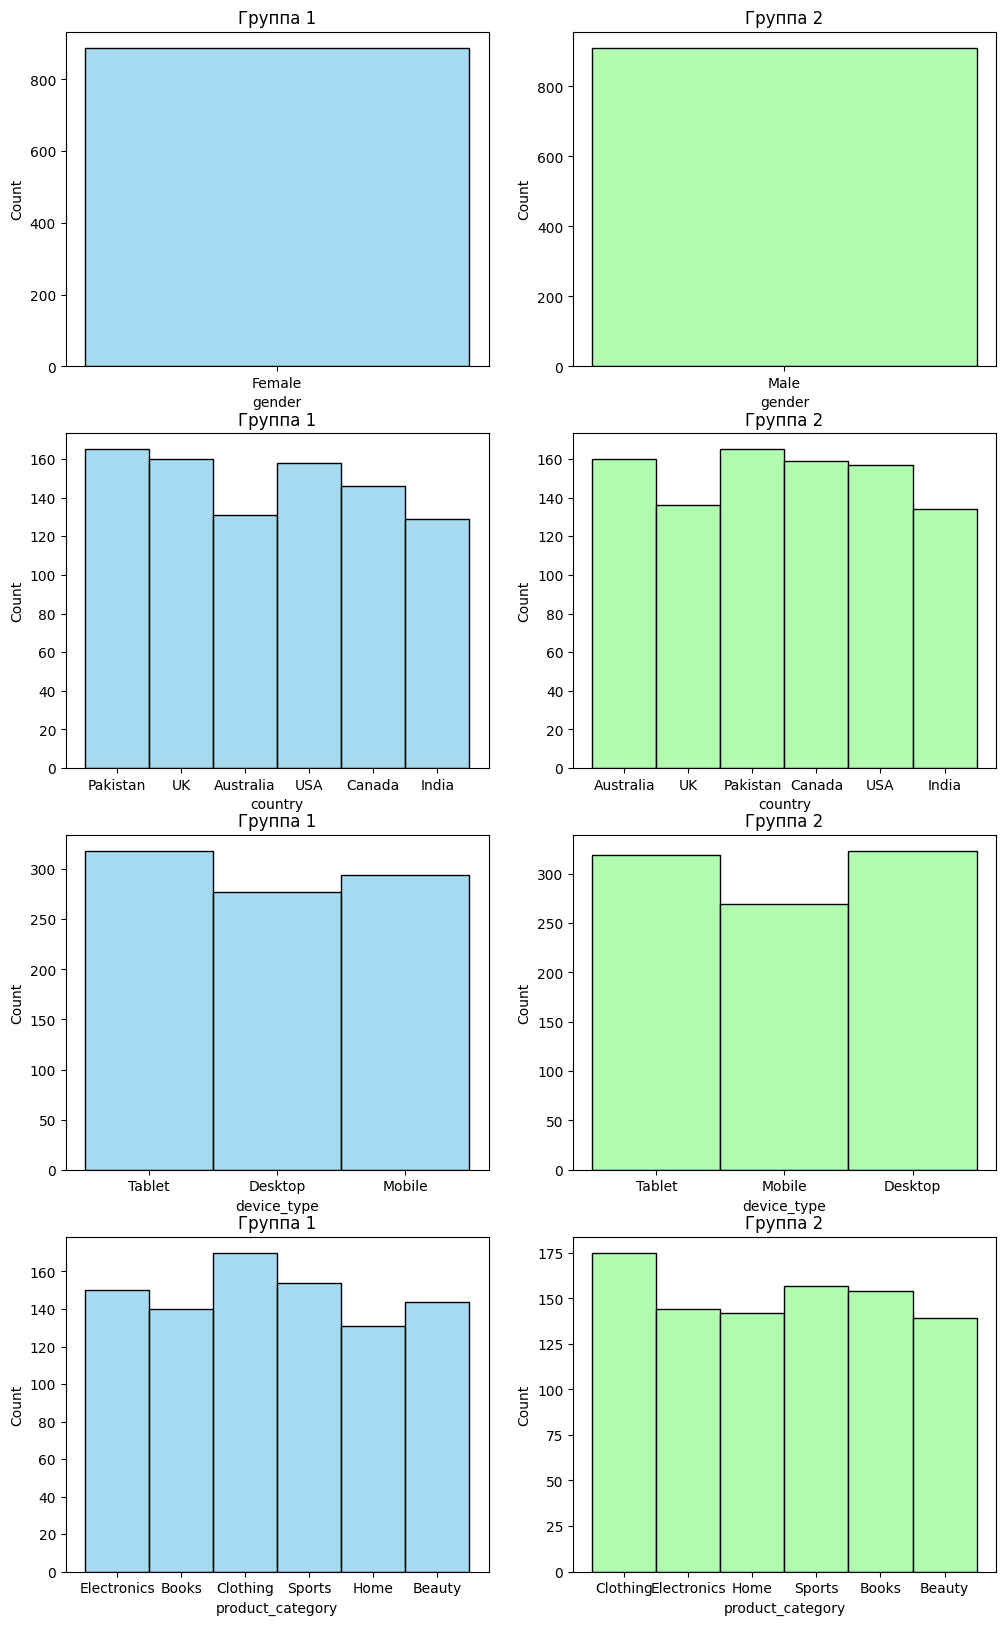

In [ ]:
inx = 1
plt.figure(figsize=(12, 20))

for col in cat_cols:
    plt.subplot(4, 2, inx)
    sns.histplot(df[df['kmeans_labels'] == 0][col],
                 color='skyblue') # Гистограмма col для первого кластера
    plt.title('Группа 1')
    plt.subplot(4, 2, inx + 1)
    sns.histplot(df[df['kmeans_labels'] == 1][col],
                 color='palegreen') # Гистограмма col для второго кластера
    plt.title('Группа 2')
    inx += 2
plt.show()

K-Means разделило группы по половому признаку. С помощью t-теста проверим, действительно ли есть разница в поведении клиентов разных полов.

In [23]:
from scipy.stats import ttest_ind

In [25]:
for col in num_cols:
    t_stat, p_value = ttest_ind(
        df[df['kmeans_labels'] == 0][col],
        df[df['kmeans_labels'] == 1][col])
    print(f"t-тест для {col}: t-stat = {t_stat:.3f}, p_value = {p_value:.3f}")

t-тест для age: t-stat = -0.215, p_value = 0.830
t-тест для time_spent_minutes: t-stat = -2.377, p_value = 0.018
t-тест для items_viewed: t-stat = 0.408, p_value = 0.684
t-тест для items_purchased: t-stat = -0.881, p_value = 0.378
t-тест для total_spent_usd: t-stat = 0.221, p_value = 0.825


## Вывод

p-value больше 0.05 говорит о статистической неразличимости групп. Выделенные кластеры представляют собой не поведенческие сегменты, а статистически идентичные группы мужчин и женщин. Реальной сегментации по поведению в данных не обнаружено.